In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download NLTK resources (Run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
data = {
    "Review": [
        "This movie was amazing with excellent acting and story.",
        "I hated this movie. It was boring and too long.",
        "The film was okay, not bad but not great either.",
        "Fantastic visuals and brilliant performances.",
        "Worst movie I have ever watched.",
        "The storyline was average and predictable.",
        "Excellent direction and wonderful music.",
        "The acting was terrible and the script was weak.",
        "It was a decent movie to watch with family.",
        "Absolutely loved every moment of this film."
    ]
}

df = pd.DataFrame(data)

print(df.head())

                                              Review
0  This movie was amazing with excellent acting a...
1    I hated this movie. It was boring and too long.
2   The film was okay, not bad but not great either.
3      Fantastic visuals and brilliant performances.
4                   Worst movie I have ever watched.


In [ ]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Text Cleaning Function
def clean_text(text):

    text = str(text).lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    cleaned_text = " ".join(words)

    return cleaned_text

In [ ]:
# Apply Cleaning
df["Cleaned_Review"] = df["Review"].apply(clean_text)

print("\nCleaned Reviews")
print(df[['Review', 'Cleaned_Review']])

# Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    score = sia.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"


Cleaned Reviews
                                              Review  \
0  This movie was amazing with excellent acting a...   
1    I hated this movie. It was boring and too long.   
2   The film was okay, not bad but not great either.   
3      Fantastic visuals and brilliant performances.   
4                   Worst movie I have ever watched.   
5         The storyline was average and predictable.   
6           Excellent direction and wonderful music.   
7   The acting was terrible and the script was weak.   
8        It was a decent movie to watch with family.   
9        Absolutely loved every moment of this film.   

                             Cleaned_Review  
0      movie amazing excellent acting story  
1                   hated movie boring long  
2                film okay bad great either  
3  fantastic visuals brilliant performances  
4                  worst movie ever watched  
5             storyline average predictable  
6       excellent direction wonderful music 

In [ ]:
# Apply Sentiment Analysis
df["Sentiment"] = df["Cleaned_Review"].apply(analyze_sentiment)

print("\nSentiment Analysis")
print(df[['Review', 'Sentiment']])


Sentiment Analysis
                                              Review Sentiment
0  This movie was amazing with excellent acting a...  Positive
1    I hated this movie. It was boring and too long.  Negative
2   The film was okay, not bad but not great either.  Positive
3      Fantastic visuals and brilliant performances.  Positive
4                   Worst movie I have ever watched.  Negative
5         The storyline was average and predictable.   Neutral
6           Excellent direction and wonderful music.  Positive
7   The acting was terrible and the script was weak.  Negative
8        It was a decent movie to watch with family.   Neutral
9        Absolutely loved every moment of this film.  Positive


In [ ]:
# Common Words
all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('movie', 4), ('excellent', 2), ('acting', 2), ('film', 2), ('amazing', 1), ('story', 1), ('hated', 1), ('boring', 1), ('long', 1), ('okay', 1)]


In [ ]:
negative_reviews = df[df["Sentiment"] == "Negative"]

negative_words = " ".join(negative_reviews["Cleaned_Review"])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))



Most Common Complaint Keywords
[('movie', 2), ('hated', 1), ('boring', 1), ('long', 1), ('worst', 1), ('ever', 1), ('watched', 1), ('acting', 1), ('terrible', 1), ('script', 1)]


Sentiment
Positive    5
Negative    3
Neutral     2
Name: count, dtype: int64


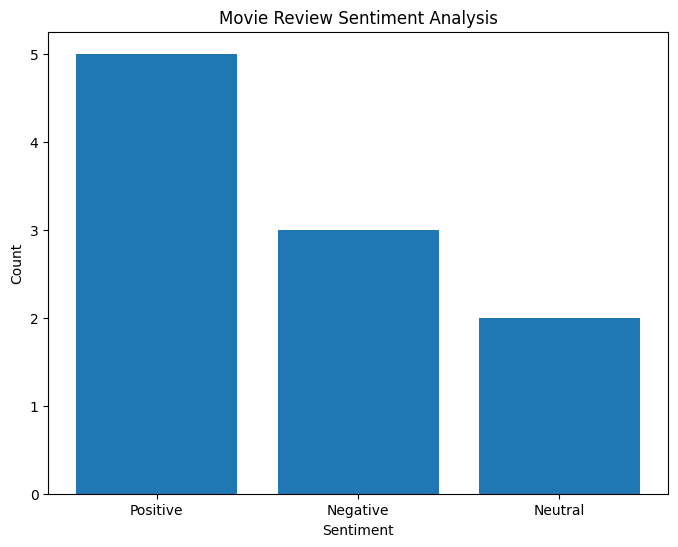

In [ ]:
# Sentiment Count
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

# Bar Chart
plt.figure(figsize=(8,6))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.title("Movie Review Sentiment Analysis")
plt.show()

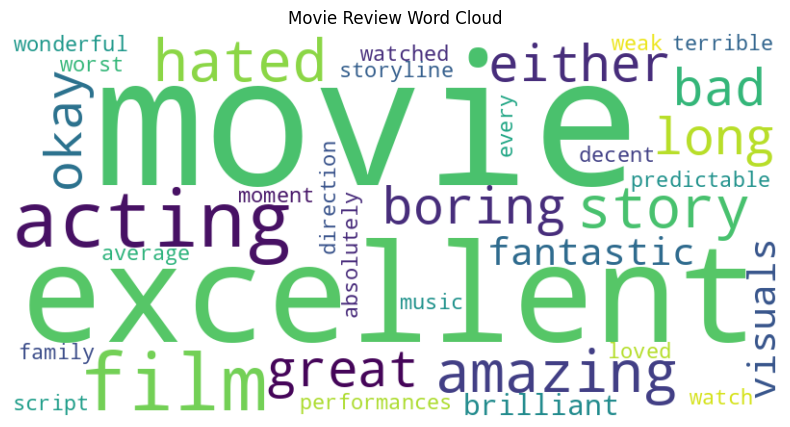

<Figure size 640x480 with 0 Axes>

In [18]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Movie Review Word Cloud")

plt.show()
plt.savefig("wordcloud.png")
plt.show()